# Cat and Dog Classification
Classify images of cats and dogs using Histogram of Oriented Gradients (HOG) for feature extraction and Decision Tree for classification. 

In [18]:
import os
import numpy as np
from skimage.io import imread
from skimage import img_as_ubyte
from sklearn.svm import SVC
from skimage.io import imsave
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [19]:
# Load dataset
data_dir = './dataset'
images, labels = [], []

for file in os.listdir(data_dir):
    if file.endswith('.jpg'):
        img_path = os.path.join(data_dir, file)
 
        if file.startswith('cat'):
            labels.append(0)  # Cat
        elif file.startswith('dog'):
            labels.append(1)  # Dog
        else:
            continue

        img = imread(img_path)
        img = rgb2gray(img)  # Convert to grayscale
        img_resized = resize(img, (128, 128), anti_aliasing=True)
        images.append(img_resized)

images = np.array(images)
labels = np.array(labels)
print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print(f'Number of cats: {np.sum(labels == 0)}')
print(f'Number of dogs: {np.sum(labels == 1)}')

Images shape: (615, 128, 128)
Labels shape: (615,)
Number of cats: 260
Number of dogs: 355


In [ ]:
def extract_hog_features(images, visualize=False):
    """Extract HOG features from a list of grayscale images.
    
    Args:
        images: Array of grayscale images (N, 128, 128).
        visualize: If True, return HOG visualizations.
    
    Returns:
        hog_features: Array of HOG features (N, feature_size).
        hog_images: Array of HOG visualizations (N, 128, 128) if visualize=True, else None.
    """
    images_hog = []
    images_visulizers = []

    orientations = 9
    pixels_per_cell = (8, 8)
    cells_per_block =(2, 2)
    for image in images :
        features, hog_image = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        visualize=visualize
        )
        images_hog.append(features)
        if visualize : images_visulizers.append(hog_image)

    image_np_feature = np.array(images_hog)
    image_np_visulizer = np.array(images_visulizers)
    return image_np_feature , image_np_visulizer
        



In [21]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from imageio import imsave  # or from skimage.io import imsave

def split_and_save_dataset(images, hog_features, labels,
                           test_size=0.2,
                           train_dir='./dog-cat/train',
                           test_dir='./dog-cat/test'):
    """
    Split dataset into training and test sets using indices,
    and save images to separate directories.

    Args:
        images (np.ndarray): Array of grayscale images (N, 128, 128).
        hog_features (np.ndarray): Array of HOG features (N, feature_size).
        labels (np.ndarray): Labels (0 for cat, 1 for dog).
        test_size (float): Fraction of data for test set.
        train_dir (str): Directory to save training images.
        test_dir (str): Directory to save test images.

    Returns:
        X_train, X_test: HOG features for training and test sets.
        y_train, y_test: Labels for training and test sets.
        idx_train, idx_test: Indices of train and test samples.
    """
    n_samples = len(images)
    idx = np.arange(n_samples)

    # Split indices
    idx_train, idx_test, y_train, y_test = train_test_split(
        idx, labels, test_size=test_size, random_state=42
    )

    # Create dirs
    for d in [train_dir, test_dir]:
        os.makedirs(d, exist_ok=True)

    # Save train images
    for i, idx_ in enumerate(idx_train, start=1):
        path = os.path.join(train_dir, f"img_{i}.png")
        imsave(path, img_as_ubyte(images[idx_]))

    # Save test images
    for i, idx_ in enumerate(idx_test, start=1):
        path = os.path.join(test_dir, f"img_{i}.png")
        imsave(path, img_as_ubyte(images[idx_]))

    X_train = np.array([hog_features[i] for i in idx_train])
    X_test = np.array([hog_features[i] for i in idx_test])
    print(f"{X_train.shape}")
    return X_train, X_test, y_train, y_test, idx_train, idx_test


In [22]:
def train_decision_tree(X_train, y_train):
    """Train a Decision Tree classifier on HOG features.
        
        Args:
            X_train: HOG features for training (N_train, feature_size).
            y_train: Training labels (0 for cat, 1 for dog).
        
        Returns:
            clf: Trained Decision Tree classifier.
    """    
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train, y_train)
    return clf


In [23]:
def Svm_model(X_train, y_train):
    clf = SVC(kernel="rbf", C=1, gamma="scale")
    clf.fit(X_train, y_train)
    return clf


In [24]:
def RandomForest_model(X_train, y_train):
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    return clf 

In [25]:
def GradientBoosting(X_train, y_train):
    from sklearn.ensemble import GradientBoostingClassifier
    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
    clf.fit(X_train, y_train)
    return clf

In [26]:
def logestic_regression(X_train, y_train):
    from sklearn.linear_model import LogisticRegression
    clf = LogisticRegression(max_iter=200)
    clf.fit(X_train, y_train)
    return clf

In [27]:
def evaluate_model(clf, X_test, y_test):
    """Evaluate the Decision Tree classifier on the test set.
    
    Args:
        clf: Trained Decision Tree classifier.
        X_test: HOG features for test set (N_test, feature_size).
        y_test: Test labels (0 for cat, 1 for dog).
    
    Returns:
        accuracy: Test set accuracy.
        y_pred: Predicted labels for test set.
    """
    y_pred = clf.predict(X_test)
    accuracy=accuracy_score(y_test, y_pred)
    return accuracy, y_pred



(492, 8100)
Test Accuracy lg: 0.9431
Test Accuracy dt: 0.8293
Test Accuracy svm: 0.9512
Test Accuracy rf: 0.9593
Test Accuracy gb: 0.9675


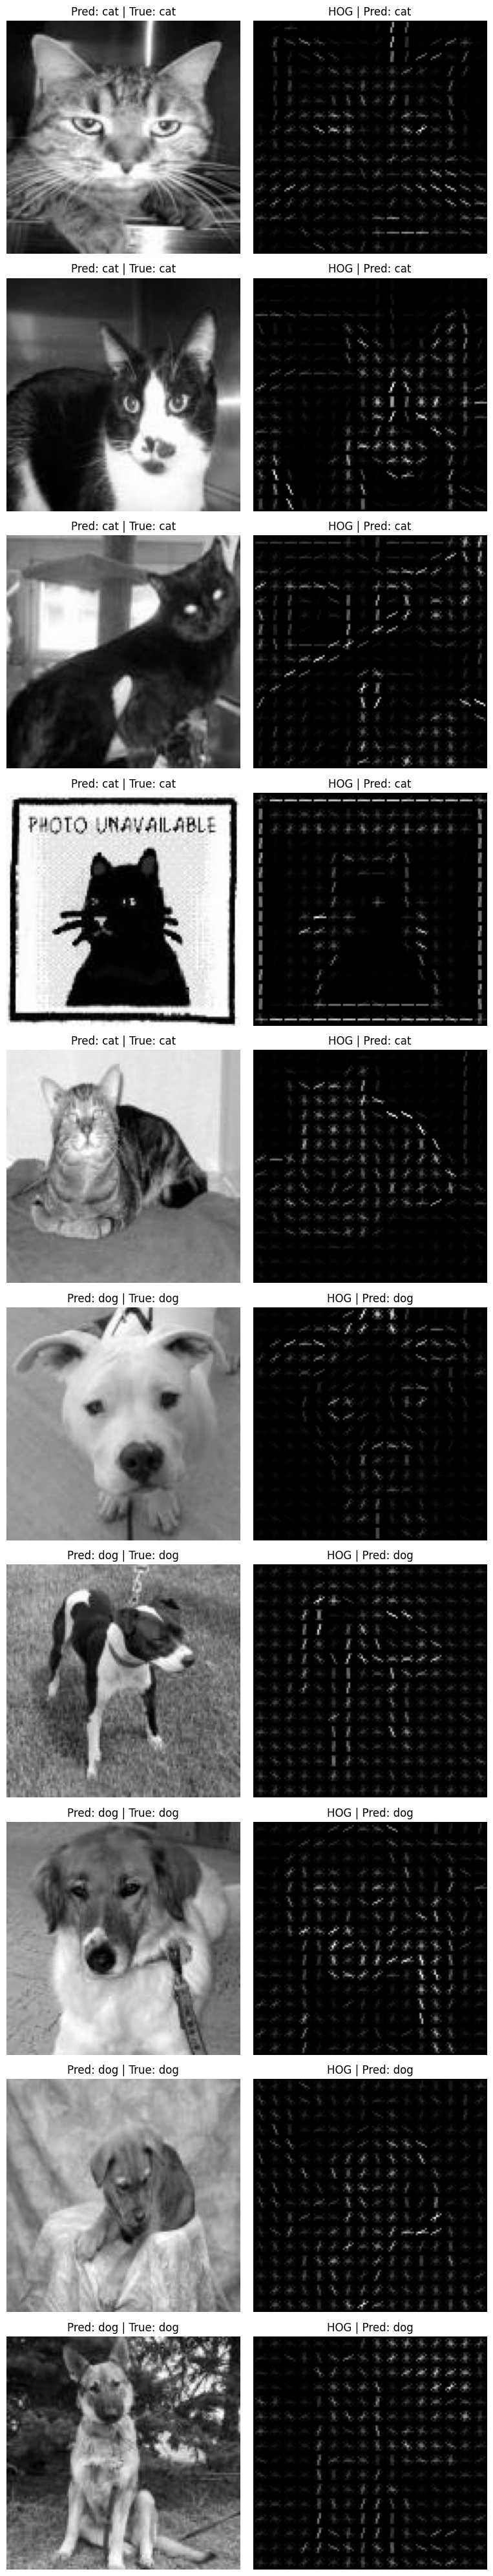

In [ ]:
# Extract HOG features

hog_features, hog_images = extract_hog_features(images, visualize=True)

# Split and save dataset
X_train, X_test, y_train, y_test , idx_train , idx_test = split_and_save_dataset(images , hog_features, labels, test_size=0.2)

# Train Decision Tree
clf_dt = train_decision_tree(X_train, y_train)
clf_svm = Svm_model(X_train, y_train)
clf_rf = RandomForest_model(X_train, y_train)
clf_gb = GradientBoosting(X_train, y_train)
clf_lg = logestic_regression(X_train, y_train)
# Evaluate model
accuracy_lg, y_pred_lg = evaluate_model(clf_lg, X_test, y_test)
print(f'Test Accuracy lg: {accuracy_lg:.4f}')
accuracy_dt, y_pred_dt = evaluate_model(clf_dt, X_test, y_test)
print(f'Test Accuracy dt: {accuracy_dt:.4f}')
accuracy_svm, y_pred_svm = evaluate_model(clf_svm, X_test, y_test)
print(f'Test Accuracy svm: {accuracy_svm:.4f}')
accuracy_rf, y_pred_rf = evaluate_model(clf_rf, X_test, y_test)
print(f'Test Accuracy rf: {accuracy_rf:.4f}')
accuracy_gb, y_pred_gb = evaluate_model(clf_gb, X_test, y_test)
print(f'Test Accuracy gb: {accuracy_gb:.4f}')

accuracy = max(accuracy_dt, accuracy_svm, accuracy_rf, accuracy_gb, accuracy_lg)
y_pred = y_pred_dt if accuracy == accuracy_dt else (y_pred_svm if accuracy == accuracy_svm else (y_pred_rf if accuracy == accuracy_rf else (y_pred_gb if accuracy == accuracy_gb else y_pred_lg)))

# Visualize results
classes = ['cat', 'dog']
cat_indices = [idx for idx in idx_test if y_test[np.where(idx_test == idx)[0][0]] == 0]
dog_indices = [idx for idx in idx_test if y_test[np.where(idx_test == idx)[0][0]] == 1]
sample_indices = cat_indices[:min(5, len(cat_indices))] + dog_indices[:min(5, len(dog_indices))]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(8, 4 * len(sample_indices)))
for i, idx in enumerate(sample_indices):
    ax = axes[i, 0] if len(sample_indices) > 1 else axes[0]
    true_label = y_test[np.where(idx_test == idx)[0][0]]
    pred_label = y_pred[np.where(idx_test == idx)[0][0]]
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f'Pred: {classes[pred_label]} | True: {classes[true_label]}')
    ax.axis('off')

    ax = axes[i, 1] if len(sample_indices) > 1 else axes[1]
    ax.imshow(hog_images[idx], cmap='gray')
    ax.set_title(f'HOG | Pred: {classes[pred_label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()